In [83]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from util import *
import os
import torch
import tensorflow as tf
from cnn.model import ConvBlock
import cnn_tf.model as tf_model
import numpy as np

In [4]:
# disable all tensorflow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [5]:
# Load config file
file_path = os.path.join(os.getcwd(), 'config_files', 'config2.txt')
config_file = load_yaml(file_path)

## Test ConvBlock

In [6]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [7]:
kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
conv_block = ConvBlock(kernel = kernel,
                       in_channels = x_torch.shape[3],
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [8]:
tf_conv_block = tf_model.ConvBlock(kernel = kernel,
                                   strides = stride,
                                   filters = filters,
                                   mu=mu, 
                                   epsilon=epsilon)

In [9]:
np.isclose(x_torch, x_tf).all()

True

In [10]:
y_torch = conv_block(x_torch).detach().numpy()
y_tf = tf_conv_block(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (1, 6, 6, 32), tensorflow: (1, 6, 6, 32)


d:\qnas_torch\cnn_tf\model.py:68: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  return tf.compat.v1.layers.conv2d(inputs=inputs,
d:\qnas_torch\cnn_tf\model.py:90: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  return tf.compat.v1.layers.batch_normalization(inputs=inputs,


In [11]:
np.isclose(y_torch, y_tf).all()

False

## Test Max Pooling

In [12]:
from cnn.model import MaxPooling

In [13]:
# create a a image tensor to test the max pooling layer
max_pool = MaxPooling(kernel=3, strides=1)
tf_max_pool = tf_model.MaxPooling(kernel=3, strides=1)

y_tf = tf_max_pool(x_tf, name="max_pool")
y_torch = max_pool(x_torch).detach().numpy()

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (1, 4, 4, 3), tensorflow: (1, 4, 4, 3)


d:\qnas_torch\cnn_tf\model.py:275: UserWarning: `tf.layers.max_pooling2d` is deprecated and will be removed in a future version. Please use `tf.keras.layers.MaxPooling2D` instead.
  return tf.compat.v1.layers.max_pooling2d(inputs=inputs,


In [14]:
np.isclose(y_torch, y_tf).all()

True

## Test Avg Pooling

In [15]:
from cnn.model import AvgPooling

avg_pool = AvgPooling(kernel=3, strides=1)
y_torch = avg_pool(x_torch).detach().numpy()

tf_avg_pool = tf_model.AvgPooling(kernel=3, strides=1)
y_tf = tf_avg_pool(x_tf, name='avg_pool')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (1, 4, 4, 3), tensorflow: (1, 4, 4, 3)


d:\qnas_torch\cnn_tf\model.py:311: UserWarning: `tf.layers.average_pooling2d` is deprecated and will be removed in a future version. Please use `tf.keras.layers.AveragePooling2D` instead.
  return tf.compat.v1.layers.average_pooling2d(inputs=inputs,


In [16]:
np.isclose(y_torch, y_tf).all()

True

## Test Fully Connected Layer

In [17]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(32, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [18]:
from cnn.model import FullyConnected

# flatten the tensor
num_features = x_torch.shape[1] * x_torch.shape[2] * x_torch.shape[3]
units = 20

fc_torch = FullyConnected(input_features=num_features, units=units)
fc_tf = tf_model.FullyConnected(units=units)

x_tor = torch.reshape(x_torch, [-1, num_features])
x_tfl = tf.reshape(x_tf, [-1, num_features])

y_torch = fc_torch(x_tor).detach().numpy()
y_tf = fc_tf(x_tfl, name='fc')

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

torch: (32, 20), tensorflow: (32, 20)


d:\qnas_torch\cnn_tf\model.py:345: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  tensor = tf.compat.v1.layers.dense(inputs=inputs,


In [19]:
np.isclose(y_torch, y_tf).all()

False

## Test Pad Feature

In [20]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 8).astype(np.float32)
X1 = np.random.rand(1, 6, 6, 6).astype(np.float32)

x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

x_torch1 = torch.from_numpy(X1)
x_tf1 = tf.convert_to_tensor(X1, dtype=tf.float32)


In [21]:
from cnn.model import pad_features

torch_tensors = [x_torch, x_torch1]
tf_tensors = [x_tf, x_tf1]


torch_padded = pad_features(tensors=torch_tensors)
tf_padded = tf_model.pad_features(tensors=tf_tensors)

torch_padded[0].shape, torch_padded[1].shape, tf_padded[0].shape, tf_padded[1].shape

(torch.Size([1, 6, 6, 8]),
 torch.Size([1, 6, 6, 8]),
 TensorShape([1, 6, 6, 8]),
 TensorShape([1, 6, 6, 8]))

## Test ResidualV1

In [22]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [23]:
from cnn.model import ResidualV1

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1 = ResidualV1(kernel = kernel,
                    in_channel = x_torch.shape[3],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

In [24]:
Res_v1

ResidualV1(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
)

In [25]:
tf_Res = tf_model.ResidualV1(kernel = kernel,
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [26]:
np.isclose(x_torch, x_tf).all()

True

In [27]:
y_torch = Res_v1(x_torch).detach().numpy()
y_tf = tf_Res(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

inputs.shape: torch.Size([1, 3, 6, 6])
tensor.shape Layer 1: torch.Size([1, 32, 6, 6])
tensor.shape Layer 2: torch.Size([1, 32, 6, 6])
inputs.shape Layer 2: torch.Size([1, 32, 6, 6])
tensor.shape Pad: torch.Size([1, 32, 6, 6])
torch: (1, 6, 6, 32), tensorflow: (1, 6, 6, 32)


d:\qnas_torch\cnn_tf\model.py:176: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  return tf.compat.v1.layers.conv2d(inputs=inputs,
d:\qnas_torch\cnn_tf\model.py:197: UserWarning: `tf.layers.batch_normalization` is deprecated and will be removed in a future version. Please use `tf.keras.layers.BatchNormalization` instead. In particular, `tf.control_dependencies(tf.GraphKeys.UPDATE_OPS)` should not be used (consult the `tf.keras.layers.BatchNormalization` documentation).
  return tf.compat.v1.layers.batch_normalization(inputs=inputs,


In [28]:
np.isclose(y_torch, y_tf).all()

False

## Test ResidualV1Pr

In [29]:
# create a tensor with numpy an convert it to pytorch tensor
X = np.random.rand(1, 6, 6, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [30]:
from cnn.model import ResidualV1Pr

kernel = 3
stride = 1
filters = 32
mu=0.9
epsilon=2e-5
Res_v1Pr = ResidualV1Pr(kernel = kernel,
                    in_channel = x_torch.shape[3],
                    strides = stride, 
                    filters = filters, 
                    mu=mu,
                    epsilon=epsilon)

Shortcut connection


In [31]:
Res_v1Pr

ResidualV1Pr(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  (shortcut): Sequential(
    (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=2e-05, momentum=0.9, affine=True, track_running_stats=True)
  )
)

In [32]:
tf_ResPR = tf_model.ResidualV1Pr(kernel = kernel,
                       strides = stride, 
                       filters = filters, 
                       mu=mu,
                       epsilon=epsilon)

In [33]:
y_torch = Res_v1Pr(x_torch).detach().numpy()
y_tf = tf_ResPR(x_tf, name="conv_block")

print(f"torch: {y_torch.shape}, tensorflow: {y_tf.shape}")

inputs.shape: torch.Size([1, 3, 6, 6])
tensor.shape Layer 1: torch.Size([1, 32, 6, 6])
tensor.shape Layer 2: torch.Size([1, 32, 6, 6])
output.shape: torch.Size([1, 32, 6, 6])
torch: (1, 6, 6, 32), tensorflow: (1, 6, 6, 32)


d:\qnas_torch\cnn_tf\model.py:209: UserWarning: `tf.layers.conv2d` is deprecated and will be removed in a future version. Please Use `tf.keras.layers.Conv2D` instead.
  return tf.compat.v1.layers.conv2d(inputs=inputs,


## Test NetworkGraph

In [34]:
import copy
import qnas_config as cfg
from cnn.model import NetworkGraph

In [35]:
phase = 'evolution'
experiment_path = 'my_exp_config2 '
config_file = 'config_files/config2.txt'

In [36]:
args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10/cifar_tfr_10000',
}

In [37]:
config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

In [38]:
fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

{'conv_1_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 32}},
 'conv_1_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 64}},
 'conv_3_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 32}},
 'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_3_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 128}},
 'conv_3_1_256': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 256}},
 'conv_5_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 32}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'max_pool_2_2': {'function': 'MaxPooling',
  'params': {'kernel': 2, 'strides': 2}},
 'avg_pool_2_2': 

In [39]:
net_list = ['conv_3_1_64', 'avg_pool_2_2', 'avg_pool_2_2', 'conv_5_1_64', 'conv_5_1_128', 'conv_5_1_64']

In [40]:
filtered_dict = {key: item for key, item in fn_dict.items() if key in net_list}
filtered_dict

{'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'avg_pool_2_2': {'function': 'AvgPooling',
  'params': {'kernel': 2, 'strides': 2}}}

In [41]:
net = NetworkGraph(num_classes=10, mu=0.99, in_channels=3)

In [42]:
filtered_dict

{'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'avg_pool_2_2': {'function': 'AvgPooling',
  'params': {'kernel': 2, 'strides': 2}}}

In [43]:
net.create_functions(fn_dict=filtered_dict, net_list=net_list)
net

NetworkGraph(
  (model): Sequential(
    (0): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
    )
    (1): AvgPooling(
      (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (2): AvgPooling(
      (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (3): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
    )
    (4): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (batch_norm): BatchNorm2d(128, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
    )
    (5): ConvBlock(
      (activation): ReLU()
      (conv): Conv2d(128, 64, k

In [44]:
X = np.random.rand(32, 64, 64, 3).astype(np.float32)
x_torch = torch.from_numpy(X)
x_tf = tf.convert_to_tensor(X, dtype=tf.float32)

In [45]:
logits = net(inputs=x_torch, debug=True)

inputs.shape: torch.Size([32, 64, 64, 3])
f: ConvBlock(
  (activation): ReLU()
  (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
)
layer output.shape: torch.Size([32, 64, 64, 64])
f: AvgPooling(
  (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
)
layer output.shape: torch.Size([32, 32, 32, 64])
f: AvgPooling(
  (avg_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
)
layer output.shape: torch.Size([32, 16, 16, 64])
f: ConvBlock(
  (activation): ReLU()
  (conv): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (batch_norm): BatchNorm2d(64, eps=2e-05, momentum=0.99, affine=True, track_running_stats=True)
)
layer output.shape: torch.Size([32, 16, 16, 64])
f: ConvBlock(
  (activation): ReLU()
  (conv): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (batch_norm): BatchNorm2d(128, eps=2e-05, momentum=0.99, affine=True,

In [46]:
logits.shape

torch.Size([32, 10])

In [47]:
fn_dict_tf

{'conv_1_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 32}},
 'conv_1_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 1, 'strides': 1, 'filters': 64}},
 'conv_3_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 32}},
 'conv_3_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 64}},
 'conv_3_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 128}},
 'conv_3_1_256': {'function': 'ConvBlock',
  'params': {'kernel': 3, 'strides': 1, 'filters': 256}},
 'conv_5_1_32': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 32}},
 'conv_5_1_64': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 64}},
 'conv_5_1_128': {'function': 'ConvBlock',
  'params': {'kernel': 5, 'strides': 1, 'filters': 128}},
 'max_pool_2_2': {'function': 'MaxPooling',
  'params': {'kernel': 2, 'strides': 2}},
 'avg_pool_2_2': 

In [48]:
filtered_dict = {key: item for key, item in fn_dict_tf.items() if key in net_list}

In [49]:
tf_net = tf_model.NetworkGraph(num_classes=10, mu=0.99)
tf_net.create_functions(fn_dict=filtered_dict)

In [50]:
tf_logits = tf_net.create_network(inputs=x_tf,net_list=net_list)
tf_logits.shape

Layer 0: conv_3_1_64
Layer 0 output shape: (32, 64, 64, 64)
Layer 1: avg_pool_2_2
Layer 1 output shape: (32, 32, 32, 64)
Layer 2: avg_pool_2_2
Layer 2 output shape: (32, 16, 16, 64)
Layer 3: conv_5_1_64
Layer 3 output shape: (32, 16, 16, 64)
Layer 4: conv_5_1_128
Layer 4 output shape: (32, 16, 16, 128)
Layer 5: conv_5_1_64
Layer 5 output shape: (32, 16, 16, 64)
FC input shape: (32, 16384)


TensorShape([32, 10])

## Pytorch Dataset

In [69]:
from dataloader import CIFAR10_loader, CIFAR100_loader, cifar10_info

In [52]:
# Example usage CIFAR10_loader
data_path = 'cifar10_data'
train_loader, val_loader = CIFAR10_loader(data_path, limit_data=10000, for_train=True, data_aug=True, batch_size=32)
test_loader = CIFAR10_loader(data_path, limit_data=10000, for_train=False, data_aug=True, batch_size=32)

Files already downloaded and verified
Files already downloaded and verified
All set for training!
Files already downloaded and verified
Files already downloaded and verified
All set for testing!


In [53]:
print(f"train_loader: {len(train_loader)}, val_loader: {len(val_loader)}, test_loader: {len(test_loader)}")

train_loader: 282, val_loader: 32, test_loader: 313


In [54]:
min = []
max = []
for batch, (imgs, labels) in enumerate(train_loader):
    print(f"batch: {batch}", end='\r')
    for i in range(len(imgs)):
        #print(f"img{i}: {imgs[i].shape}, label: {labels[i]}")
        #print(f"img{i}: Min={imgs[i].min()}, Max={imgs[i].max()}")
        min.append(imgs[i].min())
        max.append(imgs[i].max())
print("\n")
print(f"Min={np.min(min)}, Max={np.max(max)}")

batch: 281

Min=-1.9892174005508423, Max=2.126786947250366


In [55]:
class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be normalized.
        Returns:
            Tensor: Normalized image.
        """
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
            # The normalize code -> t.sub_(m).div_(s)
        return tensor
unorm = UnNormalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


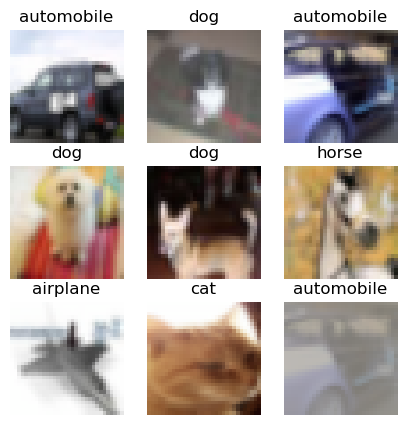

In [56]:
# plot some images of the pytorch train_loader
import matplotlib.pyplot as plt

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship','truck']
figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
train_imgs, train_labels = next(iter(train_loader))
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_imgs), size=(1,)).item()
    img, label = train_imgs[sample_idx], train_labels[sample_idx]
    img = unorm(img)
    npimg = img.numpy()
    figure.add_subplot(rows, cols, i)
    plt.title(cifar10_classes[label])
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.show()

In [57]:
# Example usage CIFAR10_loader
data_path = 'cifar100_data'
train_loader, val_loader = CIFAR100_loader(data_path, limit_data=10000, for_train=True, data_aug=True, batch_size=32)
test_loader = CIFAR100_loader(data_path, limit_data=10000, for_train=False, data_aug=True, batch_size=32)

Files already downloaded and verified
Files already downloaded and verified
All set for training!
Files already downloaded and verified
Files already downloaded and verified
All set for testing!


In [58]:
print(f"train_loader: {len(train_loader)}, val_loader: {len(val_loader)}, test_loader: {len(test_loader)}")

train_loader: 282, val_loader: 32, test_loader: 313


In [59]:
min = []
max = []
for batch, (imgs, labels) in enumerate(train_loader):
    print(f"batch: {batch}", end='\r')
    for i in range(len(imgs)):
        #print(f"img{i}: {imgs[i].shape}, label: {labels[i]}")
        #print(f"img{i}: Min={imgs[i].min()}, Max={imgs[i].max()}")
        min.append(imgs[i].min())
        max.append(imgs[i].max())
print("\n")
print(f"Min={np.min(min)}, Max={np.max(max)}")

batch: 281

Min=-1.8973376750946045, Max=2.0245516300201416


In [60]:
unorm_ = UnNormalize(mean=(0.5071, 0.4865, 0.4411), std=(0.2673, 0.2564, 0.2761))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


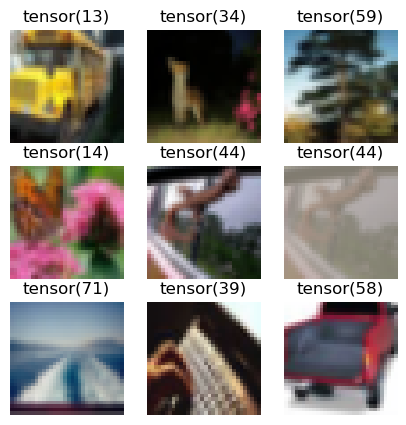

In [61]:
figure = plt.figure(figsize=(5, 5))
cols, rows = 3, 3
train_imgs, train_labels = next(iter(train_loader))
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_imgs), size=(1,)).item()
    img, label = train_imgs[sample_idx], train_labels[sample_idx]
    img = unorm_(img)
    npimg = img.numpy()
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.show()

# Train and Test

In [62]:
import copy
import qnas_config as cfg
from cnn.model import NetworkGraph

In [73]:
phase = 'evolution'
experiment_path = 'my_exp_config2'
config_file = 'config_files/config2.txt'

args = {
    'experiment_path': experiment_path,
    'config_file': config_file,
    'data_path': 'cifar10_data',
}

config = cfg.ConfigParameters(args, phase=phase)
config.get_parameters()

fn_dict=config.fn_dict
fn_dict_tf = copy.deepcopy(fn_dict)
fn_dict

net_list = ['conv_3_1_64', 'avg_pool_2_2', 'avg_pool_2_2', 'conv_5_1_64', 'conv_5_1_128', 'conv_5_1_64']

In [74]:
params = config.train_spec

In [75]:
params

{'batch_size': 256,
 'eval_batch_size': 0,
 'max_epochs': 50,
 'epochs_to_eval': 5,
 'optimizer': 'RMSProp',
 'dataset': 'Cifar10',
 'data_augmentation': True,
 'subtract_mean': True,
 'limit_data': 10000,
 'save_checkpoints_epochs': 10,
 'save_summary_epochs': 0.25,
 'threads': 0,
 'decay': 0.9,
 'learning_rate': 0.001,
 'momentum': 0.0,
 'weight_decay': 0.0001,
 'experiment_path': 'my_exp_config2'}

In [86]:
from cnn.train import fitness_calculation
from cnn.input import cifar10_info

In [78]:
data = {
    "num_classes": 10,
}

In [92]:
acc = fitness_calculation(id_num="0", data_info= data, params=params, fn_dict=fn_dict, net_list=net_list)
acc

Files already downloaded and verified
Files already downloaded and verified
All set for training!


0